# Прогнозирование температуры звезды

## 1. Подготовка данных

### Загрузка исходных данных из файла

In [34]:
!pip install -q phik

In [35]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import mean_squared_error
from itertools import product
from math import ceil

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import phik
from phik import phik_matrix
from phik.report import plot_correlation_matrix
from phik import report

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

### Загрузка файла с данными

Загрузим файл и откроем датасет

In [36]:
data = pd.read_csv('/datasets/6_class.csv')

In [37]:
data.head()

,Unnamed: 0,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color
0,0,3068,0.002400,0.1700,16.12,0,Red
1,1,3042,0.000500,0.1542,16.60,0,Red
2,2,2600,0.000300,0.1020,18.70,0,Red
3,3,2800,0.000200,0.1600,16.65,0,Red
4,4,1939,0.000138,0.1030,20.06,0,Red


Посмотрим основную информацию, содержащуюся в датасете

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              240 non-null    int64  
 1   Temperature (K)         240 non-null    int64  
 2   Luminosity(L/Lo)        240 non-null    float64
 3   Radius(R/Ro)            240 non-null    float64
 4   Absolute magnitude(Mv)  240 non-null    float64
 5   Star type               240 non-null    int64  
 6   Star color              240 non-null    object 
dtypes: float64(3), int64(3), object(1)
memory usage: 13.2+ KB


В нашем распоряжении данные о характеристиках звезд.  
В датасете 7 столбцов и 240 строк.

**числовые признаки:**
* Temperature (K)
* Luminosity(L/Lo)
* Radius(R/Ro)
* Absolute magnitude(Mv)

**категориальные признаки:** 

* Unnamed
* Star type
* Star color

## 2. Предобработка и анализ данных

Проверим наличие пропусков в датасете

In [39]:
data.isna().sum()

Unnamed: 0                0
Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
dtype: int64

Пропусков нет. Проверим наличие явных дублей.

In [40]:
data.duplicated().sum()

0

Явных дублей нет.

Рассмотрим категориальные признаки внимательнее

In [41]:
# Выведем уникальные значения в колонке Star type
data['Star type'].unique()

array([0, 1, 2, 3, 4, 5])

6 уникальных категорий звезд

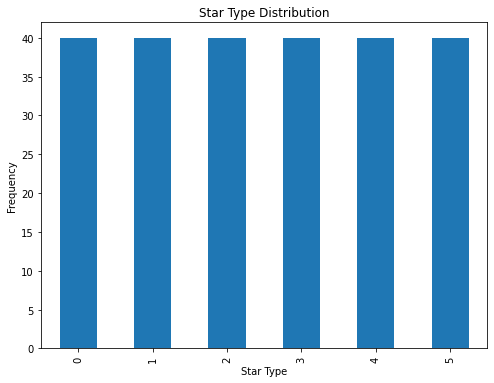

In [42]:
# Построение столбчатой диаграммы для столбца "Star type"
plt.figure(figsize=(8, 6))
data['Star type'].value_counts().plot(kind='bar')
plt.title('Star Type Distribution')
plt.xlabel('Star Type')
plt.ylabel('Frequency')
plt.show()

По 40 звезд в каждой категории

In [43]:
# Выведем уникальные значения в колонке Star color
data['Star color'].unique()

array(['Red', 'Blue White', 'White', 'Yellowish White', 'Blue white',
       'Pale yellow orange', 'Blue', 'Blue-white', 'Whitish',
       'yellow-white', 'Orange', 'White-Yellow', 'white', 'Blue ',
       'yellowish', 'Yellowish', 'Orange-Red', 'Blue white ',
       'Blue-White'], dtype=object)

В колонке с цветом звезд есть неявные дубли. Приведем их к общему виду

In [44]:
data['Star color'] = data['Star color'].str.strip()
data['Star color'] = data['Star color'].str.lower()
data['Star color'] = data['Star color'].str.replace('-', ' ')

In [45]:
data['Star color'].unique()

array(['red', 'blue white', 'white', 'yellowish white',
       'pale yellow orange', 'blue', 'whitish', 'yellow white', 'orange',
       'white yellow', 'yellowish', 'orange red'], dtype=object)

In [46]:
data['Star color'] = data['Star color'].replace({'white yellow': 'yellow white'})

In [47]:
# Проверим внесенные изменения
data['Star color'].unique()

array(['red', 'blue white', 'white', 'yellowish white',
       'pale yellow orange', 'blue', 'whitish', 'yellow white', 'orange',
       'yellowish', 'orange red'], dtype=object)

Посмотрим распределение количества звезд по их цвету. Красных звезд больше всего в датасете.

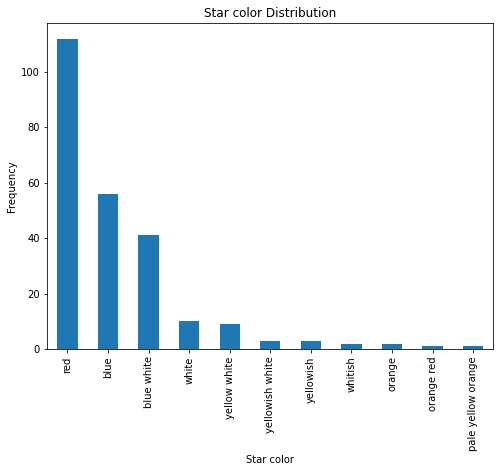

In [48]:
# Построение столбчатой диаграммы для столбца Star color
plt.figure(figsize=(8, 6))
data['Star color'].value_counts().plot(kind='bar')
plt.title('Star color Distribution')
plt.xlabel('Star color')
plt.ylabel('Frequency')
plt.show()

Проверим на всякий случай дубли в нумерации звезд. Дублей нет.

In [49]:
# Выведем уникальные значения в колонке Unnamed: 0
data['Unnamed: 0'].nunique()

240

In [50]:
data.duplicated().sum()

0

Разделим датасет на количественные и качественные значения для удобства дальнейшего анализа.

In [51]:
num = ['Temperature (K)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)']
cat = ['Star type', 'Star color']

Построим гистограмму для числовых признаков

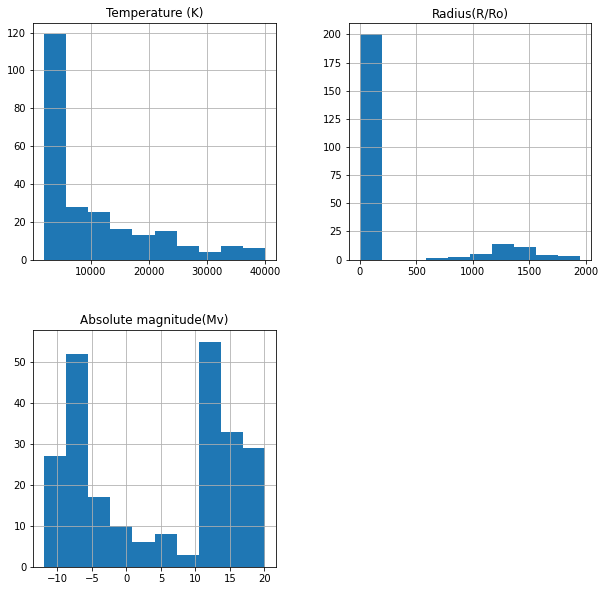

In [52]:
numeric_columns = data[num]

numeric_columns.hist(figsize=(10, 10))
plt.show()

Ненормальное распределение количественных данных, наблюдаются выбросы.

Дополнительно выведем описание количественных данных

In [53]:
data[num].describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature (K),240.0,10497.462500,9552.425037,1939.0000,3344.25000,5776.0000,15055.5000,40000.00
Radius(R/Ro),240.0,237.157781,517.155763,0.0084,0.10275,0.7625,42.7500,1948.50
Absolute magnitude(Mv),240.0,4.382396,10.532512,-11.9200,-6.23250,8.3130,13.6975,20.06


Построим графики "ящик с усами", чтобы посмотреть выбросы

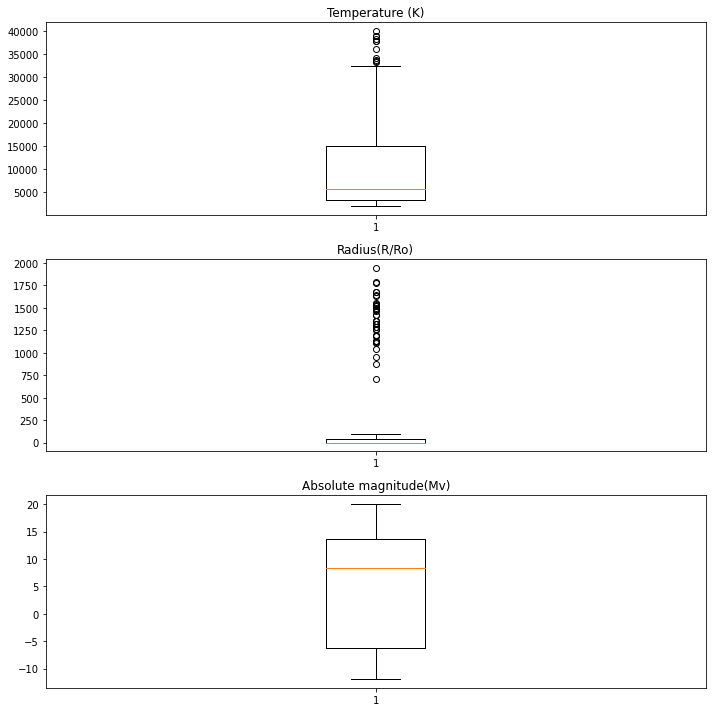

In [54]:
# Выбираем только 3 числовых столбца из списка num
numeric_columns = data[num]

# Создаем график размером 3x1
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# Перебираем числовые столбцы и соответствующие им оси графика
for ax, column in zip(axes.flatten(), numeric_columns):
    ax.set_title(column)  # Задаем заголовок графика
    ax.boxplot(data[column])  # Строим ящик с усами для текущего столбца

plt.tight_layout()  # Для лучшего расположения графиков на рисунке
plt.show()

Выбросы есть, но это связано с разнообразием типов звезд, в целом данные выглядят правдивыми относительно своей природы. Удалять ничего не будем.

Посмотрим дополнительно на взаимосвязь между целевым признаком 'Temperature (K)' и прочими. Построим графики pairplot

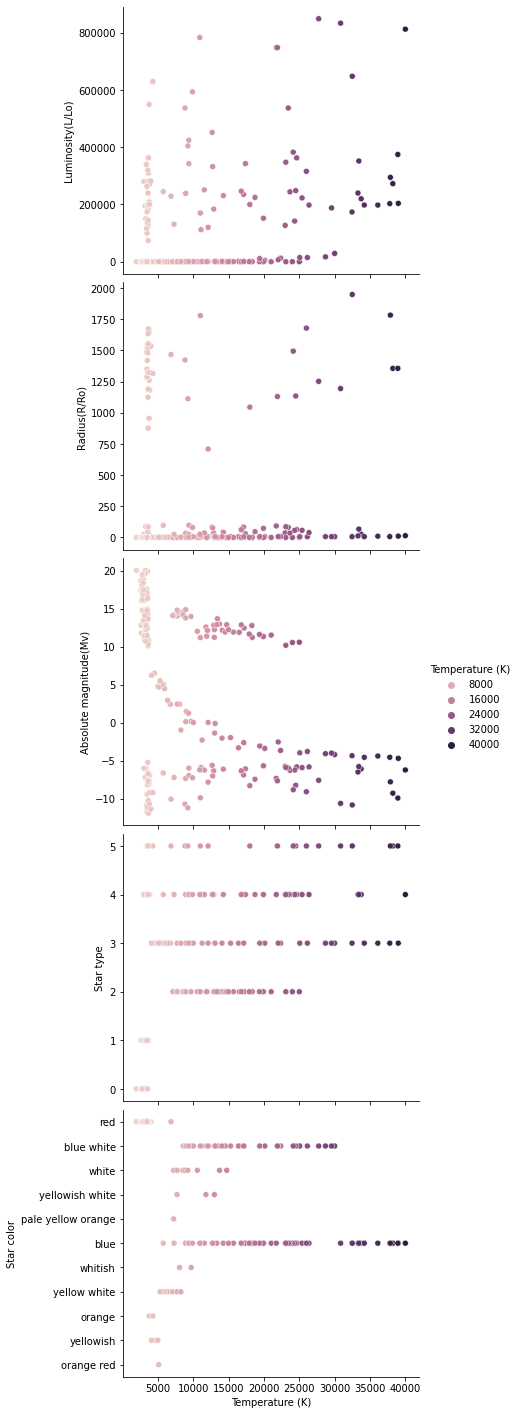

In [55]:
columns_to_compare = ['Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)', 'Star type', 'Star color']

# Построим парные графики с установкой размера и цветом точек
sns.pairplot(data, x_vars=['Temperature (K)'], 
             y_vars=columns_to_compare, 
             hue='Temperature (K)', 
             height=4, 
             aspect=1.5)

plt.show()
plt.show()

- Чем выше температура, тем ниже Абсолютная звёздная величина Absolute magnitude Mv (физическая величина, характеризующая блеск звезды)
- Также видим, что только звезды типа 3, 4, 5 (Звёзды главной последовательности, Сверхгиганты, Гипергиганты) и звезды цвета Blue имеют температуру выше 32000 К

Посмотрим корреляцию между разными признаками

interval columns not set, guessing: ['Unnamed: 0', 'Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)', 'Star type']


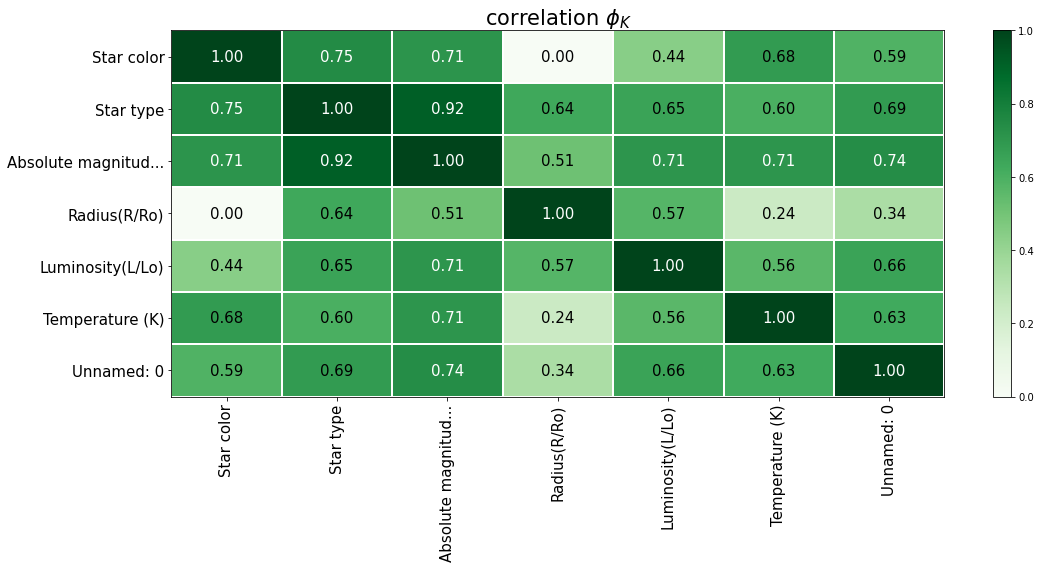

In [56]:
phik_overview = data.phik_matrix()

plot_correlation_matrix(phik_overview.values,
                        x_labels=phik_overview.columns,
                        y_labels=phik_overview.index,
                        vmin=0, vmax=1, color_map="Greens",
                        title=r"correlation $\phi_K$",
                        fontsize_factor=1.5,
                        figsize=(16, 8))
plt.tight_layout();

График корреляции показывает, что есть сильная взаимосвязь между Absolute magnitude Mv и Типом звезд (Star Type) - 0.92, а также между Типом (Star Type) и Цветом звезд (Star Color) - 0.75.

Не будем удалять эти признаки, так как у нас в целом мало данных, они нам потребуются для обучений нейросети.

Удалим только столбец с нумерацией звезд, так как этот признак не содержит ценной инфориации для обучения нейросети.

In [57]:
data = data.drop(['Unnamed: 0'], axis=1)

После удаления столбца 'Unnamed: 0' снова проверим датасет на явные дубли

In [58]:
data.duplicated().sum()

0

Дубликатов нет. Таким образом можем утвердить список признаков, которые будем использовать для обучения нейронной сети, которая поможет предсказывать абсолютную температуру (Temperature (K)) на поверхности звезды:

* Luminosity(L/Lo)   
* Radius(R/Ro)
* Absolute magnitude(Mv)
* Star type
* Star color

* Temperature (K) - целевой признак

In [59]:
data.columns

Index(['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)',
       'Absolute magnitude(Mv)', 'Star type', 'Star color'],
      dtype='object')

### Вывод

**На этапе предобработки и исследовательского анализа данных:**

- Проверили данные на пропущенные значения и явные дубликаты
- Обработали неявные дубли в колонке Star color
- Проверили распределение данных и выбросы
- Проверили данные на мультиколлениарность. Обнаружили взаимосвязь между Absolute magnitude Mv и Типом звезд (Star Type) - 0.92, а также между Типом (Star Type) и Цветом звезд (Star Color) - 0.75
- Удалили ненужные колонки: Unnamed: 0
- Утвердили список признаков, необходимый для настройки и обучения нейронной сети:
  - Luminosity(L/Lo)
  - Radius(R/Ro)
  - Absolute magnitude(Mv)
  - Star type
  - Star color
  - Temperature (K) - целевой признак

## 3. Подготовка данных к построению модели

Подготовим данные к построению нейроннной сети. Разделим датасет на целевой признак и прочие.
Разделим датасет на обучающую и тестовую выборки.
Разделим данные на категориальные и числовые. Обработаем данные: числовые признаки при помощи StandardScaler(), категориальные при помощи OneHotEncoder.

In [60]:
# Разделим данные на признаки и целевую переменную
X = data.drop(['Temperature (K)'], axis=1)
y = data['Temperature (K)']

# Разделим данные на обучающую, валидационную и тестовую выборки
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=12345)


# Определим количественные и категориальные столбцы
num_cols = ['Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)']
cat_cols = ['Star color', 'Star type']

# Конвейер предобработки
num_pipeline = Pipeline([
    ('scaler', StandardScaler())  # Масштабирование числовых признаков
])

cat_pipeline = Pipeline([
    ('ohe', OneHotEncoder(sparse=False, handle_unknown='ignore'))
])

# Объединим конвейеры с помощью ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ])

# Обучим конвейера предобработки на обучающих данных
preprocessor.fit(X_train)

# Предобработаем обучающие, валидационные и тестовые данные
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape, X_val_processed.shape, X_test_processed.shape, y_train.shape, y_val.shape, y_test.shape)

(144, 19) (48, 19) (48, 19) (144,) (48,) (48,)


## 4. Построение базовой нейронной сети

Построим простую модель нейронной сети — baseline.
Для этого преобразуем данные в тензоры PyTorch. Определим архитектуру нейронной сети: выберем количество скрытых слоёв, количество нейронов на них, функции активации на скрытых и выходном слоях. 
Проведите обучение нейронной сети.

In [61]:
# Преобразуем предобработанные данные в тензоры PyTorch
X_train_tensor = torch.FloatTensor(X_train_processed)
X_test_tensor = torch.FloatTensor(X_test_processed)
y_train_tensor = torch.FloatTensor(y_train.values)
y_test_tensor = torch.FloatTensor(y_test.values)
X_val_tensor = torch.FloatTensor(X_val_processed)
y_val_tensor = torch.FloatTensor(y_val.values)

Обучим первую модель.  

Возьмем в качестве функции активации сигмоид nn.Sigmoid(), который применим к выходу первого слоя нейронной сети 
(после первого линейного слоя).

In [62]:
# Определим параметры модели
n_in_neurons = X_train_tensor.shape[1]
n_hidden_neurons_1 = 15
n_hidden_neurons_2 = 10
n_out_neurons = 1

# Определение первой модели нейронной сети
net_1 = nn.Sequential(
    nn.Linear(n_in_neurons, n_hidden_neurons_1),
    nn.Sigmoid(),
    nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2),
    nn.ReLU(),
    nn.Linear(n_hidden_neurons_2, n_out_neurons)
)

# Определение функции потерь и оптимизатора для первой модели
loss = nn.MSELoss()
optimizer = optim.Adam(net_1.parameters(), lr=1e-3)

# Обучим модель
num_epochs = 45000
best_rmse_1 = float('inf')  # Инициализация лучшего RMSE значением
best_epoch_1 = 0  # Инициализация лучшей эпохи

for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    preds = net_1.forward(X_train_tensor).squeeze()
            
    loss_value = loss(preds, y_train_tensor)
            
    loss_value.backward()
    
    optimizer.step()
    
    if epoch % 10 == 0 or epoch % 10 == 1:
        net_1.eval()  
        val_preds_1 = net_1.forward(X_val_tensor).squeeze()  # Предсказание на валидационном наборе
        rmse_1 = torch.sqrt(loss(val_preds_1, y_val_tensor))
        print(f"Epoch {epoch+1}, RMSE on validation set for model 1: {rmse_1.item()}")
        if rmse_1 < best_rmse_1:  
            best_rmse_1 = rmse_1  
            best_epoch_1 = epoch  
        net_1.train()  

print(f"Best RMSE on validation set for model 1: {best_rmse_1.item()} at epoch {best_epoch_1+1}")

Epoch 1, RMSE on validation set for model 1: 15127.1806640625
Epoch 2, RMSE on validation set for model 1: 15127.1748046875
Epoch 11, RMSE on validation set for model 1: 15127.1181640625
Epoch 12, RMSE on validation set for model 1: 15127.1123046875
Epoch 21, RMSE on validation set for model 1: 15127.046875
Epoch 22, RMSE on validation set for model 1: 15127.0390625
Epoch 31, RMSE on validation set for model 1: 15126.978515625
Epoch 32, RMSE on validation set for model 1: 15126.9716796875
Epoch 41, RMSE on validation set for model 1: 15126.91015625
Epoch 42, RMSE on validation set for model 1: 15126.90234375
Epoch 51, RMSE on validation set for model 1: 15126.8369140625
Epoch 52, RMSE on validation set for model 1: 15126.828125
Epoch 61, RMSE on validation set for model 1: 15126.7578125
Epoch 62, RMSE on validation set for model 1: 15126.7490234375
Epoch 71, RMSE on validation set for model 1: 15126.669921875
Epoch 72, RMSE on validation set for model 1: 15126.6611328125
Epoch 81, RMSE

Лучший результат RMSE в процессе обучения первой модели: 2835.32

Обучим вторую модель.  

Теперь возьмем в качестве функции активации nn.ReLU(), который применим к выходу первого слоя нейронной сети 
(после первого линейного слоя).

In [76]:
n_in_neurons = X_train_tensor.shape[1]
n_hidden_neurons_1 = 15
n_hidden_neurons_2 = 10
n_out_neurons = 1

net_2 = nn.Sequential(
    nn.Linear(n_in_neurons, n_hidden_neurons_1),
    nn.ReLU(),
    nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2),
    nn.ReLU(),
    nn.Linear(n_hidden_neurons_2, n_out_neurons)
)

loss = nn.MSELoss()
optimizer = optim.Adam(net_2.parameters(), lr=1e-3)

num_epochs = 40000
best_rmse_2 = float('inf')
best_epoch_2 = 0

for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    preds = net_2.forward(X_train_tensor).squeeze()
            
    loss_value = loss(preds, y_train_tensor)
            
    loss_value.backward()
    
    optimizer.step()
    
    if epoch % 10 == 0 or epoch % 10 == 1:
        net_2.eval()  
        val_preds_2 = net_2.forward(X_val_tensor).squeeze()
        rmse_2 = torch.sqrt(loss(val_preds_2, y_val_tensor))
        print(f"Epoch {epoch+1}, RMSE on validation set for model 2: {rmse_2.item()}")
        if rmse_2 < best_rmse_2:  
            best_rmse_2 = rmse_2  
            best_epoch_2 = epoch  
        net_2.train()  

print(f"Best RMSE on validation set for model 2: {best_rmse_2.item()} at epoch {best_epoch_2+1}")

Epoch 1, RMSE on validation set for model 2: 15127.3076171875
Epoch 2, RMSE on validation set for model 2: 15127.3037109375
Epoch 11, RMSE on validation set for model 2: 15127.275390625
Epoch 12, RMSE on validation set for model 2: 15127.271484375
Epoch 21, RMSE on validation set for model 2: 15127.2373046875
Epoch 22, RMSE on validation set for model 2: 15127.2333984375
Epoch 31, RMSE on validation set for model 2: 15127.1904296875
Epoch 32, RMSE on validation set for model 2: 15127.185546875
Epoch 41, RMSE on validation set for model 2: 15127.1298828125
Epoch 42, RMSE on validation set for model 2: 15127.123046875
Epoch 51, RMSE on validation set for model 2: 15127.04296875
Epoch 52, RMSE on validation set for model 2: 15127.033203125
Epoch 61, RMSE on validation set for model 2: 15126.921875
Epoch 62, RMSE on validation set for model 2: 15126.90625
Epoch 71, RMSE on validation set for model 2: 15126.7578125
Epoch 72, RMSE on validation set for model 2: 15126.7392578125
Epoch 81, RMS

Получили RMSE: 4328.13

Обучим третью модель.

Вернем функцию активации nn.Sigmoid(), но заменим оптимизатор на SGD.

In [34]:
n_in_neurons = X_train_tensor.shape[1]
n_hidden_neurons_1 = 15
n_hidden_neurons_2 = 10
n_out_neurons = 1

net_3 = nn.Sequential(
    nn.Linear(n_in_neurons, n_hidden_neurons_1),
    nn.Sigmoid(),
    nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2),
    nn.ReLU(),
    nn.Linear(n_hidden_neurons_2, n_out_neurons)
)

loss = nn.MSELoss()
optimizer = optim.SGD(net_3.parameters(), lr=1e-3)

num_epochs = 60000
best_rmse_3 = float('inf')
best_epoch_3 = 0

for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    preds = net_3.forward(X_train_tensor).squeeze()
            
    loss_value = loss(preds, y_train_tensor)
            
    loss_value.backward()
    
    optimizer.step()
    
    if epoch % 10 == 0 or epoch % 10 == 1:
        net_3.eval()  
        val_preds_3 = net_3.forward(X_val_tensor).squeeze() 
        rmse_3 = torch.sqrt(loss(val_preds_3, y_val_tensor))
        print(f"Epoch {epoch+1}, RMSE on validation set for model 3: {rmse_3.item()}")
        if rmse_3 < best_rmse_3:  
            best_rmse_3 = rmse_3  
            best_epoch_3 = epoch  
        net_3.train()  

print(f"Best RMSE on validation set for model 3: {best_rmse_3.item()} at epoch {best_epoch_3+1}")

Epoch 1, RMSE on validation set for model 3: 15099.9228515625
Epoch 2, RMSE on validation set for model 3: 42754.30859375
Epoch 11, RMSE on validation set for model 3: 16313.4189453125
Epoch 12, RMSE on validation set for model 3: 16295.4697265625
Epoch 21, RMSE on validation set for model 3: 16136.005859375
Epoch 22, RMSE on validation set for model 3: 16118.5166015625
Epoch 31, RMSE on validation set for model 3: 15963.1513671875
Epoch 32, RMSE on validation set for model 3: 15946.115234375
Epoch 41, RMSE on validation set for model 3: 15794.7578125
Epoch 42, RMSE on validation set for model 3: 15778.16015625
Epoch 51, RMSE on validation set for model 3: 15630.7265625
Epoch 52, RMSE on validation set for model 3: 15614.55859375
Epoch 61, RMSE on validation set for model 3: 15470.9619140625
Epoch 62, RMSE on validation set for model 3: 15455.2158203125
Epoch 71, RMSE on validation set for model 3: 15315.3701171875
Epoch 72, RMSE on validation set for model 3: 15300.0361328125
Epoch 81

Получили совсем плохие результаты RMSE, лучшая метрика: 9846.11. Возможно, можно добиться лучшего результата, увеличив количество эпох. Но лучше просто вернем оптимизатор Adam.

Построим график "Факт — Прогноз" на основе Первой обученной модели (именно там мы получили лучший результат метрики RMSE). По горизонтальной оси будут отложены условные номера звёзд, а по вертикальной — температура в Кельвинах.

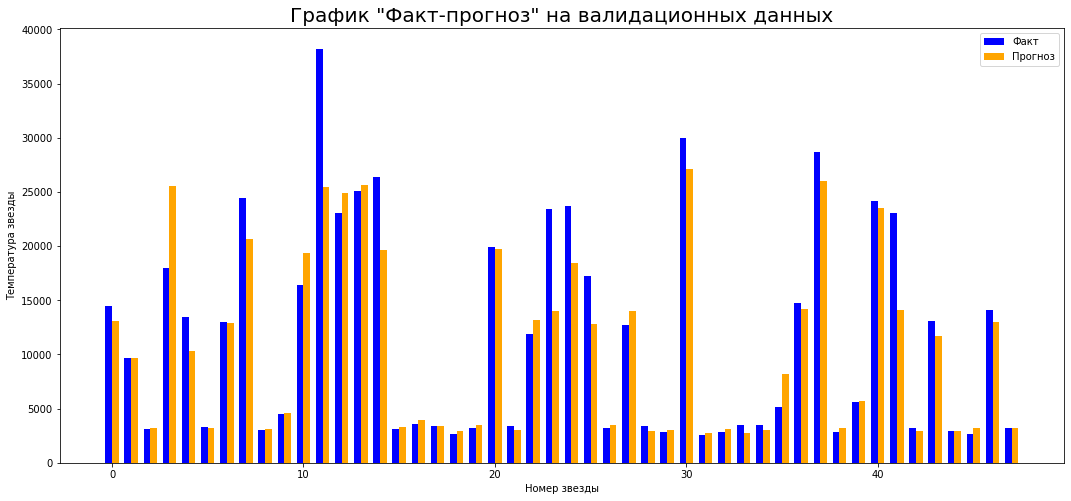

In [38]:
# Получим прогнозные значения для первой модели
val_preds_1 = net_1.forward(X_val_tensor).squeeze().detach().numpy()

def fact_forecast(val_preds, y_val):
    '''Функция для визуализации качества регрессии "Факт-прогноз" на валидационных данных'''
    y1 = val_preds
    y2 = y_val.values.reshape([-1])  # Преобразуем в массив NumPy
    x = np.arange(len(y1))

    fig, ax = plt.subplots(figsize=(18, 8))
    width = 0.35
    ax.bar(x - width/2, y2, width=0.35, label='Факт', color='blue')
    ax.bar(x + width/2, y1, width=0.35, label='Прогноз', color='orange')
    ax.legend()
    ax.set_title('График "Факт-прогноз" на валидационных данных', fontsize=20)
    ax.set_xlabel('Номер звезды')
    ax.set_ylabel('Температура звезды')
    plt.show()

# Визуализируем полученные значения
fact_forecast(val_preds_1, y_val)

На графике видим, что для звезд с низкими температурами модель предсказывает значения более точно или немного завышает эти значения. В то время, как для звезд с более высокими температурами, нейросеть в основном предсказывает заниженные значения.

### Вывод

На данном этапе исследования мы подготовили данные к построению нейроннной сети. Разделим датасет на обучающую, валидационную и тестовую выборки. Обработали числовые и категориальные признаки.

Построили простую модель нейронной сети — baseline, попробовав разные параметры: разные функции активации nn.Sigmoid() и nn.ReLU(), разные оптимизатор на Adam и SGD.

Лучший результат RMSE на валидационной выборке: 2835.32 был получен на первой модели со следующими параметрами:

n_hidden_neurons_1 = 15  
n_hidden_neurons_2 = 10  
Linear()  
Sigmoid()  
функция потерь MSELoss()  
оптимизатор Adam  
количество эпох 45000  

Попробуем улучшить модель с базовыми параметрами.

## 5. Улучшение нейронной сети

Добавим в базовую модель перебор параметров нейросети: «dropout» и «размер батча». 
Архитектуру нейронной сети оставим, как в первой модели, чтобы сравнить результат.

Четвертая модель

In [31]:
# Определим список параметров для перебора
dropout_values = [0.0, 0.1, 0.2, 0.3]
batch_sizes = [4, 6, 8, 10, 16, 32]

n_in_neurons = X_train_tensor.shape[1]
n_hidden_neurons_1 = 15
n_hidden_neurons_2 = 10
n_out_neurons = 1

loss = nn.MSELoss()

# Настроим цикл перебора параметров и обучения модели для каждой комбинации
for dropout, batch_size in product(dropout_values, batch_sizes):
    print(f"Training model with dropout={dropout}, batch_size={batch_size}")
    
    net_4 = nn.Sequential(
        nn.Linear(n_in_neurons, n_hidden_neurons_1),
        nn.Sigmoid(),
        nn.Dropout(dropout),
        nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(n_hidden_neurons_2, n_out_neurons)
    )

    optimizer = optim.Adam(net_4.parameters(), lr=1e-3)

    num_epochs = 45000
    num_batches = ceil(len(X_train_tensor) / batch_size)

    for epoch in range(num_epochs):
        order = np.random.permutation(len(X_train_tensor))
        for batch_idx in range(num_batches):
            start_index = batch_idx * batch_size
            optimizer.zero_grad()
  
            batch_indexes = order[start_index:start_index+batch_size]
            X_batch = X_train_tensor[batch_indexes]
            y_batch = y_train_tensor[batch_indexes]
  
            preds = net_4.forward(X_batch).flatten()
        
            loss_value = loss(preds, y_batch)

            loss_value.backward()
        
            optimizer.step()

    if epoch % 10 == 0 or epoch == num_epochs - 1:
        net_4.eval()
        val_preds_4 = net_4.forward(X_val_tensor).squeeze()
        rmse = torch.sqrt(loss(val_preds_4, y_val_tensor)).item()
        print(f"RMSE: {rmse}")

Training model with dropout=0.0, batch_size=4
RMSE: 3705.3994140625
Training model with dropout=0.0, batch_size=6
RMSE: 4588.52197265625
Training model with dropout=0.0, batch_size=8
RMSE: 4713.52880859375
Training model with dropout=0.0, batch_size=10
RMSE: 4146.4765625
Training model with dropout=0.0, batch_size=16
RMSE: 3491.326416015625
Training model with dropout=0.0, batch_size=32
RMSE: 3527.38134765625
Training model with dropout=0.1, batch_size=4
RMSE: 3687.365478515625
Training model with dropout=0.1, batch_size=6
RMSE: 3553.038818359375
Training model with dropout=0.1, batch_size=8
RMSE: 3259.182373046875
Training model with dropout=0.1, batch_size=10
RMSE: 3412.375732421875
Training model with dropout=0.1, batch_size=16
RMSE: 3622.6982421875
Training model with dropout=0.2, batch_size=4
RMSE: 3414.54345703125
Training model with dropout=0.2, batch_size=6
RMSE: 3602.496826171875
Training model with dropout=0.2, batch_size=8
RMSE: 3680.11865234375
Training model with dropout=0

Лучший результат RMSE: 3259.18 был получен с dropout=0.1 и batch_size=8

Усложним модель, добавив инициализацию весов init.xavier_uniform

Пятая модель

In [32]:
# Определение списка параметров для перебора
dropout_values = [0.0, 0.1, 0.2, 0.3]
batch_sizes = [4, 6, 8, 10, 16, 32]

# Определение параметров модели, которые не будут изменяться
n_in_neurons = X_train_tensor.shape[1]
n_hidden_neurons_1 = 15
n_hidden_neurons_2 = 10
n_out_neurons = 1

loss = nn.MSELoss()

# Инициализация весов
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

# Перебор параметров и обучение модели для каждой комбинации
for dropout, batch_size in product(dropout_values, batch_sizes):
    print(f"Training model with dropout={dropout}, batch_size={batch_size}")
    
    # Определение модели нейронной сети
    net_5 = nn.Sequential(
        nn.Linear(n_in_neurons, n_hidden_neurons_1),
        nn.Sigmoid(),
        nn.Dropout(dropout),
        nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(n_hidden_neurons_2, n_out_neurons)
    )

    # Применение инициализации весов к модели
    net_5.apply(init_weights)

    optimizer = optim.Adam(net_5.parameters(), lr=1e-3)

    num_epochs = 45000
    num_batches = ceil(len(X_train_tensor) / batch_size)

    for epoch in range(num_epochs):
        order = torch.randperm(len(X_train_tensor))
        for batch_idx in range(num_batches):
            start_index = batch_idx * batch_size
            optimizer.zero_grad()
  
            batch_indexes = order[start_index:start_index+batch_size]
            X_batch = X_train_tensor[batch_indexes]
            y_batch = y_train_tensor[batch_indexes]
  
            preds = net_5.forward(X_batch).flatten()
        
            loss_value = loss(preds, y_batch)

            loss_value.backward()
        
            optimizer.step()

    if epoch % 10 == 0 or epoch == num_epochs - 1:
        net_5.eval()
        val_preds_5 = net_5.forward(X_val_tensor).squeeze()
        rmse = torch.sqrt(loss(val_preds_5, y_val_tensor)).item()
        print(f"RMSE: {rmse}")

Training model with dropout=0.0, batch_size=4
RMSE: 4062.932861328125
Training model with dropout=0.0, batch_size=6
RMSE: 4526.296875
Training model with dropout=0.0, batch_size=8
RMSE: 4449.98291015625
Training model with dropout=0.0, batch_size=10
RMSE: 4575.05419921875
Training model with dropout=0.0, batch_size=16
RMSE: 3849.4501953125
Training model with dropout=0.0, batch_size=32
RMSE: 3906.76904296875
Training model with dropout=0.1, batch_size=4
RMSE: 3545.523681640625
Training model with dropout=0.1, batch_size=6
RMSE: 3719.308349609375
Training model with dropout=0.1, batch_size=8
RMSE: 3596.934326171875
Training model with dropout=0.1, batch_size=10
RMSE: 3687.84912109375
Training model with dropout=0.1, batch_size=16
RMSE: 3570.61962890625
Training model with dropout=0.1, batch_size=32
RMSE: 3659.685302734375
Training model with dropout=0.2, batch_size=4
RMSE: 3640.274169921875
Training model with dropout=0.2, batch_size=6
RMSE: 3486.112060546875
Training model with dropout

Лучший результат RMSE: 3486.11 был получен с dropout=0.2, batch_size=6

Построим график "Факт — Прогноз" на основе Четвертой модели (именно там мы получили лучший результат метрики RMSE). По горизонтальной оси будут отложены условные номера звёзд, а по вертикальной — температура в Кельвинах.

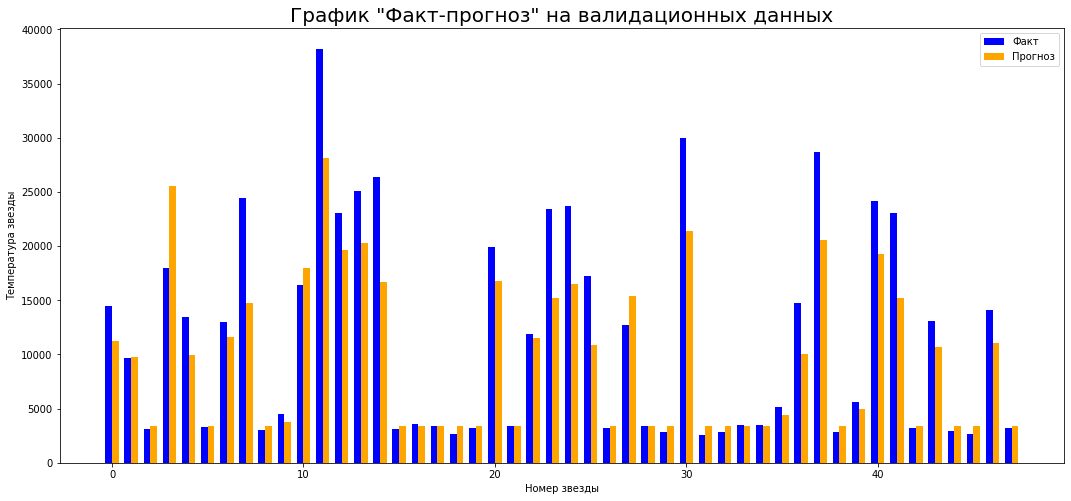

In [68]:
# Получение прогнозных значений для четвертой модели
val_preds_4 = net_4.forward(X_val_tensor).squeeze().detach().numpy()

# Обновленная функция для визуализации качества регрессии "Факт-прогноз" на валидационных данных
def fact_forecast(val_preds, y_val):
    '''Функция для визуализации качества регрессии "Факт-прогноз" на валидационных данных'''
    y1 = val_preds
    y2 = y_val.values.reshape([-1])  # Преобразуем в массив NumPy
    x = np.arange(len(y1))

    fig, ax = plt.subplots(figsize=(18, 8))
    width = 0.35
    ax.bar(x - width/2, y2, width=0.35, label='Факт', color='blue')
    ax.bar(x + width/2, y1, width=0.35, label='Прогноз', color='orange')
    ax.legend()
    ax.set_title('График "Факт-прогноз" на валидационных данных', fontsize=20)
    ax.set_xlabel('Номер звезды')
    ax.set_ylabel('Температура звезды')
    plt.show()

# Визуализируем полученные значения для четвертой модели
fact_forecast(val_preds_4, y_val)


Видим примерно такую же ситуацию, что и в случае с первой моделью, но результаты предсказания хуже.
Для звезд с низкими температурами модель завышает предсказанные значения. В то время, как для звезд с более высокими температурами, нейросеть предсказывает заниженные значения.

Выведем результаты всех моделей в таблицу

| Модель № | n_hidden_neurons_1 | n_hidden_neurons_2 | Функция активации | Оптимизатор | Количество эпох | Dropout | Batch Size | Инициализация весов | Best RMSE |
|----------|---------------------|---------------------|------------------|-------------|------------------|---------|------------|---------------------|-----------|
| 1        | 15                  | 10                  | nn.Sigmoid()     | Adam        | 45000            | -       | -          | -                   | 2835.32   |
| 2        | 15                  | 10                  | nn.ReLU()        | Adam        | 40000            | -       | -          | -                   | 4245.85   |
| 3        | 15                  | 10                  | nn.Sigmoid()     | SGD         | 60000            | -       | -          | -                   | 9846.11   |
| 4        | 15                  | 10                  | nn.Sigmoid()     | Adam        | 45000            | 0.1     | 8          | -                   | 3259.18   |
| 5        | 15                  | 10                  | nn.Sigmoid()     | Adam        | 45000            | 0.2     | 6          | nn.init.xavier_uniform_ | 3486.11   |


Первая модель показазала лучшие результаты RMSE на валидационной выборке. Эту модель мы возьмем для получения предсказаний на тестовой выборке.

In [85]:
# Сделаем предсказание на тестовой выборке
net_1.eval()
test_preds = net_1.forward(X_test_tensor).squeeze()

# Вычислим RMSE
test_rmse = torch.sqrt(loss(test_preds, y_test_tensor)).item()
print(f"RMSE на тестовой выборке: {test_rmse}")

RMSE на тестовой выборке: 4720.130859375


По сравнению с результатом RMSE на валидационной выборке - 2835.32, тестовая показала результат хуже - 4720.13
Это говорит о том, что первая модель была переобучена.

## Выводы

Цель исследования заключалась в разработке нейронной сети, которая поможет предсказывать абсолютную температуру Temperature (K) на поверхности звезды.

В ходе исследования:

1.Были загружены и изучены исходные данные из файла 
2. Данные были предобработаны и был проведен исследовательский анализа

- Проверили данные на пропущенные значения и явные дубликаты
- Обработали неявные дубли в колонке Star color
- Проверили распределение данных и выбросы
- Проверили данные на мультиколлениарность. Обнаружили взаимосвязь между Absolute magnitude Mv и Типом звезд (Star Type) - 0.92, а также между Типом (Star Type) и Цветом звезд (Star Color) - 0.75
- Удалили ненужные колонки: Unnamed: 0
- Утвердили список признаков, необходимый для настройки и обучения нейронной сети:
Luminosity(L/Lo)  
Radius(R/Ro)  
Absolute magnitude(Mv)  
Star type  
Star color  
Temperature (K) - целевой признак  

3. Данные были подготовлены к построению нейроннной сети.

4. Была построена простая модель нейронной сети — baseline с комбинацией разных параметров: функции активации nn.Sigmoid() и nn.ReLU(), оптимизаторы на Adam и SGD, количество эпох и т.д.

Лучший результат RMSE на валидационной выборке baseline: 2835.32  

5. Улучшили модель с базовыми параметрами, добавив перебор параметров нейросети: «dropout», «размер батча» и инициализацию весов init.xavier.

Лучший результат RMSE на валидационной выборке: 3259.18  

| Модель № | n_hidden_neurons_1 | n_hidden_neurons_2 | Функция активации | Оптимизатор | Количество эпох | Dropout | Batch Size | Инициализация весов | Best RMSE |
|----------|---------------------|---------------------|------------------|-------------|------------------|---------|------------|---------------------|-----------|
| 1        | 15                  | 10                  | nn.Sigmoid()     | Adam        | 45000            | -       | -          | -                   | 2835.32   |
| 2        | 15                  | 10                  | nn.ReLU()        | Adam        | 40000            | -       | -          | -                   | 4245.85   |
| 3        | 15                  | 10                  | nn.Sigmoid()     | SGD         | 60000            | -       | -          | -                   | 9846.11   |
| 4        | 15                  | 10                  | nn.Sigmoid()     | Adam        | 45000            | 0.1     | 8          | -                   | 3259.18   |
| 5        | 15                  | 10                  | nn.Sigmoid()     | Adam        | 45000            | 0.2     | 6          | nn.init.xavier_uniform_ | 3486.11   |


Первая модель показазала лучшие результаты RMSE на валидационной выборке. Поэтому эту модель мы взяли для получения предсказаний на тестовой выборке.

RMSE на тестовой выборке всего лишь 4720.13, говорит о том, что первая модель была переобучена.